In [66]:
import torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os
from scipy.io import loadmat
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [67]:
try:
    from tqdm import tqdm
except ImportError:
    import sys
    !{sys.executable} -m pip install tqdm -q
    from tqdm import tqdm

try:
    import pywt
except ImportError:
    import sys
    !{sys.executable} -m pip install PyWavelets -q
    import pywt

try:
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
except ImportError:
    import sys
    !{sys.executable} -m pip install scikit-image -q
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [68]:
import os
import time
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.io import loadmat
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [69]:
class MRIDataset(Dataset):
    def __init__(self, root_dir):
        self.images = []
        print("Carregando dataset...")
        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.endswith(".mat"):
                    path = os.path.join(root, f)
                    data = loadmat(path)
                    if "x" not in data:
                        continue
                    x = data["x"]
                    for i in range(x.shape[2]):
                        img = x[:, :, i]
                        img = (img - img.min())/(img.max() - img.min() + 1e-8)
                        self.images.append(img.astype(np.float32))
        print("Total imagens:", len(self.images))

    def __getitem__(self, idx):
        x = torch.tensor(self.images[idx]).float()
        x = (x - x.mean())/(x.std() + 1e-8)
        x = x.unsqueeze(0).unsqueeze(0)
        x = F.interpolate(x, size=(192,192), mode='bilinear', align_corners=False)
        x = x.squeeze(0)
        return x

    def __len__(self):
        return len(self.images)

In [70]:
dataset_path = "/kaggle/input/datasets/semnickcharlie/brain-dataset1"
dataset = MRIDataset(dataset_path)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

Carregando dataset...
Total imagens: 4020


In [71]:
def create_variable_density_mask(shape, acceleration, calib_size=24, poly_order=4.0, device='cpu'):
    H, W = shape
    center_y, center_x = H / 2.0, W / 2.0
    y = np.arange(H) - center_y
    x = np.arange(W) - center_x
    yy, xx = np.meshgrid(y, x, indexing='ij')
    dist = np.clip(np.sqrt((yy/(H/2))**2 + (xx/(W/2))**2), 0.0, 1.0)
    pdf = (1.0 - dist) ** poly_order
    pdf = pdf / pdf.sum()

    n_total = H * W
    n_samples = int(n_total / acceleration)

    calib_y = slice(H//2 - calib_size//2, H//2 + calib_size//2)
    calib_x = slice(W//2 - calib_size//2, W//2 + calib_size//2)

    mask = np.zeros((H, W), dtype=np.float32)
    mask[calib_y, calib_x] = 1.0
    n_calib = mask.sum()

    remaining = n_samples - int(n_calib)
    if remaining > 0:
        pdf[calib_y, calib_x] = 0.0
        pdf = pdf / pdf.sum()
        idxs = np.random.choice(n_total, size=remaining, replace=False, p=pdf.ravel())
        mask.flat[idxs] = 1.0

    return torch.from_numpy(mask).to(device)


class WaveletTransform:
    def __init__(self, wavelet='db4', level=4):
        self.wavelet = wavelet
        self.level = level
        self.slices = None
        self.shape = None

    def _init_slices(self, shape):
        if self.slices is not None and self.shape == shape:
            return
        dummy = np.zeros(shape)
        coeffs = pywt.wavedec2(dummy, self.wavelet, level=self.level, mode='periodization')
        _, self.slices = pywt.coeffs_to_array(coeffs)
        self.shape = shape

    def forward(self, img):
        self._init_slices(img.shape)
        coeffs = pywt.wavedec2(img, self.wavelet, level=self.level, mode='periodization')
        arr, _ = pywt.coeffs_to_array(coeffs)
        return arr

    def inverse(self, arr, shape):
        self._init_slices(shape)
        coeffs = pywt.array_to_coeffs(arr, self.slices, output_format='wavedec2')
        img = pywt.waverec2(coeffs, self.wavelet, mode='periodization')
        return img[:shape[0], :shape[1]]


def total_variation_gradient(img):
    dy = np.zeros_like(img)
    dx = np.zeros_like(img)
    dy[:-1, :] = img[1:, :] - img[:-1, :]
    dx[:, :-1] = img[:, 1:] - img[:, :-1]
    eps = 1e-8
    norm = np.sqrt(dy**2 + dx**2 + eps)
    grad = np.zeros_like(img)
    grad[:-1, :] -= dy[:-1, :] / norm[:-1, :]
    grad[1:, :]  += dy[:-1, :] / norm[:-1, :]
    grad[:, :-1] -= dx[:, :-1] / norm[:, :-1]
    grad[:, 1:]  += dx[:, :-1] / norm[:, :-1]
    return grad


def fft2c(img):
    return np.fft.fftshift(np.fft.fft2(img, norm='ortho'))

def ifft2c(kspace):
    return np.fft.ifft2(np.fft.ifftshift(kspace), norm='ortho')

def soft_threshold(x, t):
    return np.sign(x) * np.maximum(np.abs(x) - t, 0.0)

In [72]:
def cs_reconstruct(kspace_us, mask, n_iter=200, lam_wavelet=0.005, lam_tv=0.001,
                    wavelet='db4', level=4, use_continuation=True,
                    use_dc_layer=True, warm_start=True, verbose=False):
    dev = kspace_us.device
    H, W = kspace_us.shape

    y = kspace_us.detach().cpu().numpy()
    m = mask.detach().cpu().numpy().astype(np.float64)
    y_ortho = y  # <-- CORRIGIDO: kspace_us já veio de fft2c (ortho), não dividir de novo

    x = np.real(ifft2c(y_ortho)) if warm_start else np.zeros((H, W), dtype=np.float64)
    z = x.copy()
    t_fista = 1.0

    Wt = WaveletTransform(wavelet=wavelet, level=level)

    def A(img):  return fft2c(img) * m
    def At(k):   return np.real(ifft2c(k))

    def dc_layer(img):
        if not use_dc_layer:
            return img
        k = fft2c(img)
        k = k * (1 - m) + y_ortho * m
        return np.real(ifft2c(k))

    if use_continuation:
        lam_w_seq = lam_wavelet * (10.0 ** np.linspace(0, -2, n_iter))
        lam_tv_seq = lam_tv * (10.0 ** np.linspace(0, -2, n_iter))
    else:
        lam_w_seq = np.full(n_iter, lam_wavelet)
        lam_tv_seq = np.full(n_iter, lam_tv)

    for it in range(n_iter):
        grad = At(A(z) - y_ortho)
        x_temp = z - grad

        coeffs = soft_threshold(Wt.forward(x_temp), lam_w_seq[it])
        x_prox = Wt.inverse(coeffs, (H, W))

        if lam_tv > 0:
            x_prox = x_prox - lam_tv_seq[it] * total_variation_gradient(x_prox)

        x_new = dc_layer(x_prox)

        t_new = (1.0 + np.sqrt(1.0 + 4.0 * t_fista**2)) / 2.0
        z = x_new + ((t_fista - 1.0) / t_new) * (x_new - x)
        x, t_fista = x_new, t_new

        if verbose and (it % 20 == 0 or it == n_iter - 1):
            print(f"  Iter {it+1}/{n_iter} | lam_w={lam_w_seq[it]:.5f}")

    return torch.tensor(x, dtype=torch.float32, device=dev)

In [73]:
def normalize_image(img):
    img = img.astype(np.float64)
    lo, hi = img.min(), img.max()
    return (img - lo) / (hi - lo) if hi - lo > 1e-10 else img

def compute_metrics(gt, pred):
    gt_n, pred_n = normalize_image(gt), normalize_image(pred)
    psnr = peak_signal_noise_ratio(gt_n, pred_n, data_range=1.0)
    ssim = structural_similarity(gt_n, pred_n, data_range=1.0)
    nmse = np.sum((gt - pred)**2) / (np.sum(gt**2) + 1e-12)
    return {'PSNR': psnr, 'SSIM': ssim, 'NMSE': nmse}

In [74]:
N_IMAGES = 30
ACCELERATION = 4.0

results = []
for idx in tqdm(range(min(N_IMAGES, len(dataset))), desc="Reconstruindo"):
    img = dataset[idx]                       # shape (1, 192, 192)
    gt = img.squeeze().cpu().numpy()          # (192, 192)
    H, W = gt.shape

    mask = create_variable_density_mask((H, W), ACCELERATION, device=device)
    kspace = torch.from_numpy(fft2c(gt)).to(device)
    kspace_us = kspace * mask

    t0 = time.time()
    zf_rec = np.abs(ifft2c(kspace_us.cpu().numpy()))
    time_zf = time.time() - t0

    t0 = time.time()
    cs_rec = cs_reconstruct(kspace_us, mask, n_iter=200,
                             lam_wavelet=0.005, lam_tv=0.001,
                             verbose=(idx == 0))
    cs_np = cs_rec.cpu().numpy()
    time_cs = time.time() - t0

    m_zf = compute_metrics(gt, zf_rec)
    m_cs = compute_metrics(gt, cs_np)

    results.append({
        'idx': idx,
        'psnr_zf': m_zf['PSNR'], 'psnr_cs': m_cs['PSNR'],
        'ssim_zf': m_zf['SSIM'], 'ssim_cs': m_cs['SSIM'],
        'nmse_zf': m_zf['NMSE'], 'nmse_cs': m_cs['NMSE'],
        'time_zf': time_zf, 'time_cs': time_cs,
    })

df = pd.DataFrame(results)
print(df.describe())
df.to_csv("resultados_cs_realdata.csv", index=False)

Reconstruindo:   0%|          | 0/30 [00:00<?, ?it/s]

  Iter 1/200 | lam_w=0.00500
  Iter 21/200 | lam_w=0.00315
  Iter 41/200 | lam_w=0.00198
  Iter 61/200 | lam_w=0.00125
  Iter 81/200 | lam_w=0.00079
  Iter 101/200 | lam_w=0.00049
  Iter 121/200 | lam_w=0.00031
  Iter 141/200 | lam_w=0.00020
  Iter 161/200 | lam_w=0.00012
  Iter 181/200 | lam_w=0.00008


Reconstruindo:   3%|▎         | 1/30 [00:01<00:40,  1.39s/it]

  Iter 200/200 | lam_w=0.00005


Reconstruindo: 100%|██████████| 30/30 [00:42<00:00,  1.43s/it]

             idx    psnr_zf    psnr_cs    ssim_zf    ssim_cs    nmse_zf  \
count  30.000000  30.000000  30.000000  30.000000  30.000000  30.000000   
mean   14.500000  18.250415  27.929447   0.360969   0.779889   1.142457   
std     8.803408   3.509686   3.391101   0.090173   0.069074   0.294721   
min     0.000000  14.596629  21.458676   0.281607   0.668562   0.377579   
25%     7.250000  16.157810  24.974432   0.312071   0.733515   1.063420   
50%    14.500000  17.305870  27.232388   0.330599   0.771706   1.214698   
75%    21.750000  18.551343  30.766961   0.363838   0.848933   1.299127   
max    29.000000  29.745658  33.638374   0.711532   0.877514   1.541036   

         nmse_cs    time_zf    time_cs  
count  30.000000  30.000000  30.000000  
mean    0.008936   0.000746   1.415567  
std     0.002010   0.000164   0.052972  
min     0.005600   0.000587   1.347438  
25%     0.007257   0.000645   1.378708  
50%     0.009089   0.000718   1.400254  
75%     0.010453   0.000788   1.43548

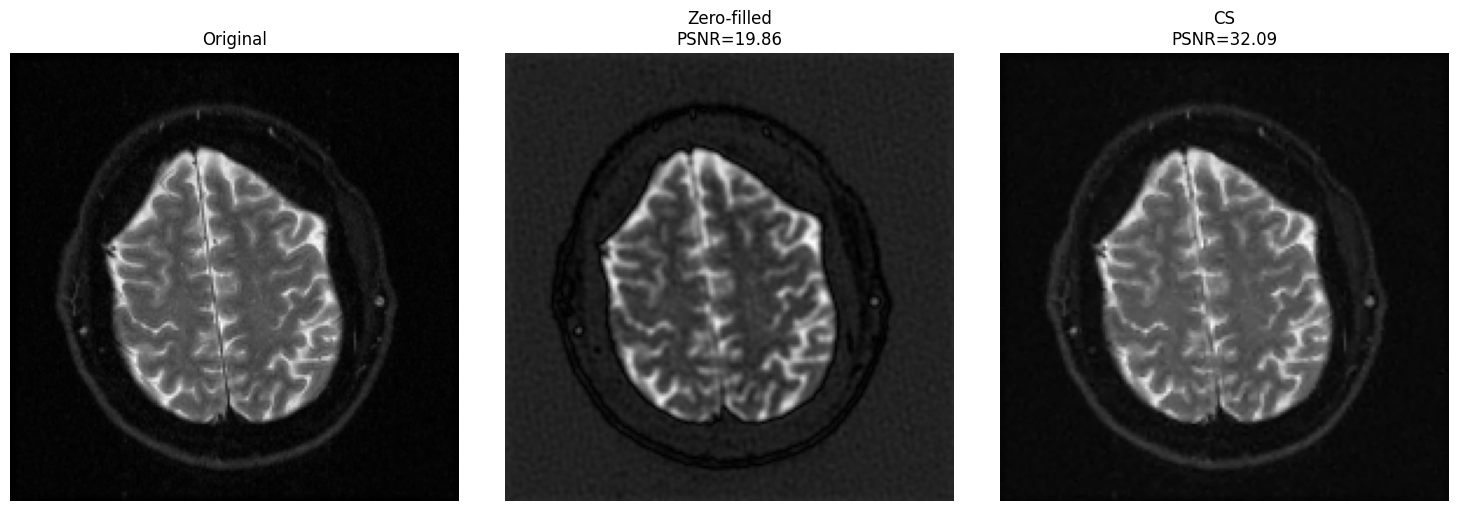

In [75]:
sample_idx = 5
img = dataset[sample_idx]
gt = img.squeeze().cpu().numpy()
H, W = gt.shape

mask = create_variable_density_mask((H, W), ACCELERATION, device=device)
kspace = torch.from_numpy(fft2c(gt)).to(device)
kspace_us = kspace * mask

zf = np.abs(ifft2c(kspace_us.cpu().numpy()))
cs = cs_reconstruct(kspace_us, mask, n_iter=200, lam_wavelet=0.005, lam_tv=0.001).cpu().numpy()

m_zf, m_cs = compute_metrics(gt, zf), compute_metrics(gt, cs)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(zf, cmap='gray'); axes[1].set_title(f"Zero-filled\nPSNR={m_zf['PSNR']:.2f}"); axes[1].axis('off')
axes[2].imshow(cs, cmap='gray'); axes[2].set_title(f"CS\nPSNR={m_cs['PSNR']:.2f}"); axes[2].axis('off')
plt.tight_layout()
plt.show()